<a href="https://colab.research.google.com/github/pmaniraj55/MyWork/blob/MachineLearning/ImageClassification.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Saving test_image.jpg to test_image (2).jpg


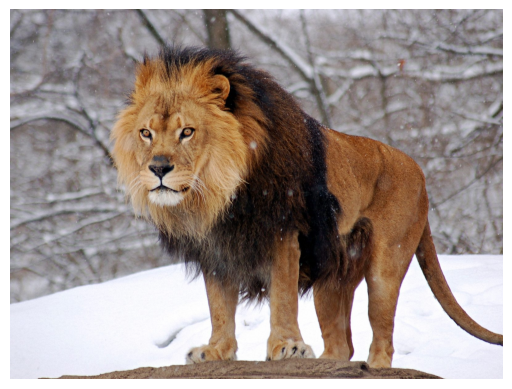

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 791ms/step
n02129165,lion,1.00
n02115913,dhole,0.00
n02112137,chow,0.00
Predictions saved to Prediction.txt


In [ ]:
#Image Classification Tool - Python using Pre-trained model (eg: MobileNet)

from PIL import Image
import numpy as np

#Test image
from google.colab import files
uploaded = files.upload()

try:
    img = Image.open("test_image.jpg")
    img.show()
except Exception as e:
    print("Error:", e)

import matplotlib.pyplot as plt
plt.imshow(img)
plt.axis('off')
plt.show()


#IMAGE LOADER
class ImageLoader:
  def __init__(self,image_path):
    self.image_path=image_path

  #Load
  def load_image(self):
    try:
      image=Image.open(self.image_path)
      image=image.convert("RGB")
      return image
    except Exception as e:
      print(f"Error loading:{e}")
      return None

  #Prepare for ML model (pyTorch)
  def preprocess(self, image, target_size=(224,224)):
    image=image.resize(target_size)
    image_array=np.array(image)/225.0 #convert image to pixel (Array of element)
    #image_array = preprocess_input(image_array) #instead of div by 255
    return np.expand_dims(image_array,axis=0) #Batch size

#MODELMANAGER
from tensorflow.keras.applications.mobilenet import MobileNet
from tensorflow.keras.applications.mobilenet import preprocess_input

class ModelManager:
  def __init__(self):
    self.model=MobileNet(weights='imagenet')

  def load_model(self):
    return self.model

  def predict(self,model,preprocessed_image):
    predictions=model.predict(preprocessed_image)
    return predictions

#Classifier
from tensorflow.keras.applications.mobilenet import decode_predictions

class Classifier:
  def __init__(self,image_path):
    self.image_loader=ImageLoader(image_path)
    self.model_manager=ModelManager()

  def classify(self):
    image=self.image_loader.load_image()
    if image is None:
      return "Invalid image"

    preprocessed_image = self.image_loader.preprocess(image)
    model=self.model_manager.load_model()
    predictions=self.model_manager.predict(model,preprocessed_image)
    decoded_predictions = decode_predictions(predictions,top=3) #Raw to top-3 prediction
    return decoded_predictions #Human readable labels

#File handling
class FileHandler:
  @staticmethod
  def save_predictions(predictions,filename = "Prediction.txt"):
    with open(filename,"w") as file: #with -> ensure file closing
      for label,description,probability in predictions[0]:
        file.write(f"{label}:{description}:{probability:.2f}\n")
      print(f"Predictions saved to {filename}")

#Main function
if __name__ == "__main__":
  image_path=r"test_image.jpg"
  classifier=Classifier(image_path)
  results = classifier.classify()

  if isinstance(results,str):
    print(results)
  else:
    for label, description, probability in results[0]:
      print(f"{label},{description},{probability:.2f}")

    FileHandler.save_predictions(results)




